# Figure 5 — Gnocchi's GC bias comes from its regional adjustment, and from fitting that adjustment on the wrong population

Five panels, one argument. Each is written to `output/fig5{A..E}.pdf` as a standalone
vector file for assembly in Illustrator.

| | Claim | Quantity |
|---|---|---|
| **A** | The bias is *introduced by* the regional adjustment, not inherited from the context-only model | mean standardized rank vs GC, for $r\equiv1$ and for full Gnocchi |
| **B** | That adjustment's GC dependence is wholly non-CpG — and $r_{\mathrm{CpG}}\approx1$ is *correct*, because methylation already carries it in step 1 | $r_{\mathrm{eff}}=E_2/E_1$, decomposed by CpG status |
| **C** | The DNM training set is not the scored population: at high GC it is mostly coding, or sequence dropped for failing gnomAD's variant-call QC | composition of the training sites per GC bin |
| **D** | Restricting the training set to the scored population flattens the empirical DNM rate — and the fit then tracks it | fitted and empirical $P(\mathrm{DNM})$, non-CpG, three training populations |
| **E** | Refitting $r$ on the scored population removes the bias in Gnocchi itself | panel A's statistic, with the retrained Gnocchi added |

A and E are the same statistic on the same windows, so they are read as before/after.
B, C and D explain what happens in between.

In [1]:
%matplotlib inline
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# Works whether the kernel's cwd is fig5/ (Jupyter's default) or the repo root.
_HERE = os.path.abspath("")
if os.path.basename(_HERE) != "fig5" and os.path.isdir(os.path.join(_HERE, "fig5")):
    _HERE = os.path.join(_HERE, "fig5")
_REPO_ROOT = os.path.dirname(_HERE)
for p in (_REPO_ROOT, _HERE):
    if p not in sys.path:
        sys.path.insert(0, p)

import config
import data as D
import depletion_rank as DR
import panels

print("repo root:", _REPO_ROOT)

repo root: /Users/petermchale/gnomad_nc_constraint


## Configuration

**Two inputs are not in this repo** and must be supplied by hand. Both live in
**`fig5/config.py`**, not in the cell below, because `fig5/refit.py` reads them from
there too — see below for why that matters.

`DEPLETION_RANK_BED` — panel A's third curve. From the constraint-tools
`CONSTRAINT_TOOLS_DATA` path used by
`papers/neutral_models_are_biased/9.regression/experiment.1.ipynb`:

```
{CONSTRAINT_TOOLS_DATA}/depletion_rank_scores/41586_2022_4965_MOESM3_ESM.noncoding.enhancer.BGS.gBGC.GC_content.bed
```

Left `None`, panel A builds with two curves instead of three and prints a notice.

`GENEHANCER_BED` — the enhancer-exclusion half of McHale et al.'s "neutral" window
definition. GeneHancer is licensed and cannot be downloaded here. Left `None`,
*neutral* means noncoding + `pass_qc` + autosome/PAR throughout.

**Why this one is not just a notebook constant.** It defines the analyzed window set,
which is used in two separate processes: `refit.py -population scored` uses it to decide
which training sites survive the restriction (what the model is *fit* on), and this
notebook uses it to decide which windows the panels are *evaluated* on. If those
disagree, the model is trained on one population and scored on another — precisely the
defect this figure is about. Both read it from `fig5/config.py`, so they cannot
disagree within a run; and since refits persist on disk across edits, `refit.py` stamps
the value it used into `refits/provenance.json` and `data.refit_path` refuses a refit
built under a different setting. Change `config.py` and you get a loud error naming the
refit to rerun.

**Prerequisite.** Panels B, D and E read the three refits, which are produced by

```
.venv/bin/python fig5/refit.py -population full
.venv/bin/python fig5/refit.py -population scored
.venv/bin/python fig5/refit.py -population sizematched
```

(~6 min each), into the repo-root `refits/` — one copy of each table, also read
directly by `dnm_training_size/`. `D.refit_path` raises with the exact
command if one is missing or was built under a different `GENEHANCER_BED`.

In [2]:
CACHE_DIR = os.path.join(_REPO_ROOT, "published")  # Chen et al.'s downloaded data
OUTPUT_DIR = D.OUTPUT_DIR                     # fig5/output
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Set these in fig5/config.py, NOT here -- fig5/refit.py reads them from there too.
DEPLETION_RANK_BED = config.DEPLETION_RANK_BED
GENEHANCER_BED = config.GENEHANCER_BED
print(f"DEPLETION_RANK_BED = {DEPLETION_RANK_BED!r}\nGENEHANCER_BED     = {GENEHANCER_BED!r}")

N_BINS = D.N_BINS           # 20
XRANGE = D.XRANGE           # (0.2, 0.73), visually matched to Fig. 2A
MIN_N_WINDOWS = 100         # drop GC bins holding fewer windows than this
MIN_N_SITES = 500           # ... or fewer training sites, in panels C and D
MIN_N_CPG = 100             # ... in the supporting CpG figure, whose top bins ARE the
                            # claim (n = 356 and 169); error bars carry the uncertainty
FIGSIZE = (7.0, 4.6)


def save(fig, letter):
    "One vector PDF per panel, for assembly in Illustrator. PNG alongside for review."
    for ext, kw in ((".pdf", {}), (".png", {"dpi": 200})):
        fig.savefig(os.path.join(OUTPUT_DIR, f"fig5{letter}{ext}"), bbox_inches="tight", **kw)
    print("wrote", os.path.join(OUTPUT_DIR, f"fig5{letter}.pdf"))

DEPLETION_RANK_BED = None
GENEHANCER_BED     = None


## Where the model comes from, and where bias can enter

*Migrated from `chen_formula/chen_formula.tex` §§1–5 (Peter McHale), which this notebook
replaces.*

**Expected SNVs under neutrality.** In a selectively neutral window, the expected number
of polymorphic sites — a site being polymorphic if an ALT allele is seen in one or more
members of the cohort — is

$$\sum_i p_{c_i}(x_i),$$

where $i$ indexes single-nucleotide sites, $x_i$ is a vector of regional features (GC
content, replication timing, …) at site $i$, $c_i$ is its sequence and methylation
context, and $p_c(x)$ is the probability that a site of context $c$ with features $x$ is
polymorphic — which of course also depends on cohort size.

**Uniformity within a window.** Assume the feature vectors of all sites in a window $w$
are approximately equal, $x_i = x_w$. Then

$$\sum_i p_{c_i}(x_w) \;=\; \sum_c n_c^{(w)}\, p_c(x_w),$$

grouping the left-hand terms by context, with $n_c^{(w)}$ the number of sites in $w$ of
context $c$.

**The naive way to fit $p_c$.** The natural approach is a parametric model

$$p_c(x) = \sigma(\beta_c \cdot x)$$

with $\sigma$ the logistic function, trained per context $c$ on a genome-wide set of
sites that are monomorphic or polymorphic in the cohort.

**Why that fails: the training set is contaminated by selection, and the contamination
correlates with $x$.** Those training sites ought to be selectively neutral, but we do
not know how to identify neutral sites in the noncoding genome, where functional
annotation is sparse and imprecise. Worse, the sites under selection *correlate with the
features* — promoters are under selection and are GC-rich — so $p_c(x)$ comes out
inaccurate precisely in the tails of the $x$ distribution.

**Chen et al.'s two-stage fix.** De novo mutations have by definition not been exposed to
selection, so they report inherent mutability. They cannot be used directly — we want a
polymorphism probability, which scales with cohort size, not a DNM rate, which does not —
but they can be brought in as a *ratio*. Factorize:

$$p_c(x) = r_c(x)\, p_c(\bar x), \qquad r_c(x) = \frac{p_c(x)}{p_c(\bar x)},$$

with $\bar x$ the average of $x$ over the windows of interest, so $r_c$ is a
feature-dependent multiplicative adjustment to a feature-independent baseline.

*Step 1* estimates $p_c(\bar x)$ by maximum likelihood over the noncoding genome,

$$p_c(\bar x) \;\approx\; \frac{N_c^{(p)}}{N_c^{(m)} + N_c^{(p)}},$$

with $N_c^{(m)}, N_c^{(p)}$ the numbers of monomorphic and polymorphic sites of context
$c$. With that many training examples, most of them near $\bar x$, this is accurate —
subject to low levels of contamination by selection.

*Step 2* assumes the polymorphism probability is approximately proportional to the DNM
probability $\hat p_c(x)$ in a training set of DNMs and matched background sites, so that

$$r_c(x) \;\approx\; \frac{\hat p_c(x)}{\hat p_c(\bar x)},
\qquad \hat p_c(x) = \sigma(\hat\beta_c \cdot x).$$

Two consequences follow immediately, and both matter later. $\hat p_c$ is sensitive to the
class balance of the training set (the DNM-to-background ratio), but $r_c$, being a ratio
of two such probabilities, **is not** — this is why panel D's levels are not comparable
across populations while panel B's $r$ is. And although the DNM training set can be
trusted to be neutral even in the tails, it is *far* smaller than the set behind
$p_c(\bar x)$, so $r_c$ is the noisier of the two factors by construction.

**Two places the implementation departs from this derivation**, both established in
`preconditions/` and both load-bearing below:

1. $r$ is fit **per trinucleotide context only**, not per $c = (\text{trinucleotide},
   \text{methylation})$. Methylation enters in step 1 alone, through $p_c(\bar x)$. That
   is why $r_{\mathrm{CpG}} \approx 1$ in panel B is *correct* rather than a failure — the
   large methylation effect has already been applied upstream.
2. The published Methods state $r$ as a ratio of **logits**; the code computes the ratio
   of **probabilities** written above. The code is what produced the published scores
   (`preconditions/verify_logit_predict_behavior.py`).

## Notation

Index 1 kb windows by $w$. Chen et al.'s model is a product of two factors. Write
$c=(t,m)$ for a *class* of possible SNV: trinucleotide context $t$ (32 of them) and
methylation level $m$. Let $n_c(w)$ be the number of gnomAD-callable sites of class $c$
in window $w$, and $p_c$ the fitted per-site mutation probability for that class
(`fitted_po`, keyed by $(t,\mathrm{ref},\mathrm{alt},m)$).

**Step 1 — sequence context and methylation only.**

$$E_1(w) \;=\; \sum_c n_c(w)\, p_c .$$

**Step 2 — the regional adjustment.** For each context $t$ a logistic regression is fit
on de novo mutations, then

$$r_t(w) \;=\; \frac{\sigma\!\big(\beta_{t0} + \boldsymbol\beta_t^{\!\top} \mathbf z_t(w)\big)}{\sigma(\beta_{t0})},
\qquad
E_2(w) \;=\; \sum_c n_c(w)\, p_c\, r_{t(c)}(w),$$

where $\mathbf z_t(w)$ is the standardized, PCA-transformed vector of regional features
at $w$ and $\sigma$ is the logistic function. Two consequences are used throughout:

1. $r$ is a **ratio of predicted probabilities**, so a *level* error in the fitted model
   — one common to numerator and denominator — cancels exactly and never reaches
   Gnocchi. Only feature-driven *variation* survives.
2. $r_t$ does **not** depend on methylation: there is one model per trinucleotide
   context, pooling all 16 methylation levels.

(The paper's Methods state $r=\boldsymbol\beta\cdot\mathbf x(w)\,/\,\boldsymbol\beta\cdot\bar{\mathbf x}$,
a ratio of *logits*. The code computes the ratio of probabilities above, and the code is
what produced the published scores.)

**The score.** With $O(w)$ the observed count of rare variants,

$$\chi^2_M(w)=\frac{\big(O(w)-E_M(w)\big)^2}{E_M(w)},
\qquad
z_M(w) = -\operatorname{sign}\!\big(O(w)-E_M(w)\big)\sqrt{\chi^2_M(w)}$$

for $M\in\{1,2\}$, keeping $|z|\le 10$ — so high $z$ means constrained. Standardizing to
a rank within the analyzed window set,

$$\rho_M(w)=\frac{\operatorname{rank}\big(z_M(w)\big)-\tfrac12}{n},$$

which is uniform on $(0,1)$ by construction. **Panels A and E plot
$\;\overline{\rho}_M(g)=\mathbb E\big[\rho_M(w)\,\big|\,w\in g\big]$** for GC bins $g$.
An unbiased metric sits at $0.5$ in every bin; departure from $0.5$ *is* the bias.

## Panel A — the bias is introduced by the regional adjustment

Both curves are computed on one window population, with the two $z$ statistics filtered
jointly and ranked *after* that filter, so they describe exactly the same windows. The
only difference between them is whether $r$ was applied.

Depletion rank is an independently constructed metric on **Halldorsson's own windows**,
so it is ranked within its own set and overlaid, never joined on `element_id`. That is
legitimate here precisely because $\rho$ is uniform on $(0,1)$ for every curve: what is
compared is how each metric's uniform mass redistributes across GC.

Summary statistic quoted in the text: $\;\overline{|\overline{\rho}_M(g)-0.5|}\;$ across bins.

**Why this statistic is so sensitive to $r$** — worth recording, because it is what
licenses reading panels B–D as the *cause* of panel A. Suppose a window's adjustment is a
uniform inflation, $E_2 = f E_1$, and write the observed count as $O = E_1(1+\epsilon)$.
Then

$$z_2 - z_1 = \sqrt{E_1}\left[\frac{f-1-\epsilon}{\sqrt{f}} + \epsilon\right]
\;\approx\; \sqrt{E_1}\,(f-1) \qquad (f \to 1,\ \epsilon \to 0).$$

The $\sqrt{E_1}$ prefactor is the point. A typical analyzed window has $E_1 \approx 174$,
so $\sqrt{E_1} \approx 13$, and a mere 10% inflation displaces $z$ by more than one unit —
comparable to the spread of $z$ itself. Measured directly by re-ranking the real
genome-wide $z$ distribution under a uniform $f$, the mean rank moves from 0.500 at
$f = 1$ to 0.687 at $f = 1.10$ and 0.302 at $f = 0.90$. Small multiplicative errors in $r$
are not a second-order concern; they are the whole effect.

In [3]:
df_win = D.window_table(CACHE_DIR, genehancer_bed=GENEHANCER_BED)
edges = D.gc_edges(df_win["GC_content"].to_numpy(), N_BINS)
print(f"analyzed window set: {df_win.height:,} windows, "
      f"GC {df_win['GC_content'].min():.3f}-{df_win['GC_content'].max():.3f}")

df_a, binned_a = D.rank_curves(df_win, min_n=MIN_N_WINDOWS)
gc_mean = float(df_a["GC_content"].mean())
binned_a

analyzed window set: 1,843,559 windows, GC 0.140-0.837
  sanity check: z_step2 vs published z, max |diff| = 0.0 over 1,843,559 windows


  1,840,310 windows after joint z filtering
  mean |rank - 0.5|  step1        = 0.093  (over bins with n >= 100)
  mean |rank - 0.5|  step2        = 0.212  (over bins with n >= 100)


gc_bin,n,gc_mid,mean_step1,se_step1,mean_step2,se_step2
i64,u32,f64,f64,f64,f64,f64
0,2,0.157,0.133854,0.073397,0.338234,0.31193
1,41,0.19678,0.346163,0.041601,0.457317,0.049759
2,1210,0.236177,0.333394,0.006788,0.285144,0.006944
3,23714,0.268477,0.377781,0.001677,0.306085,0.001576
4,127703,0.300542,0.41977,0.000756,0.354876,0.000711
…,…,…,…,…,…,…
15,993,0.676921,0.335248,0.008938,0.856879,0.007291
16,503,0.712757,0.283838,0.012123,0.867125,0.009655
17,256,0.747621,0.261728,0.016675,0.877301,0.013496


DEPLETION_RANK_BED is not set -- panel A gets two curves instead of three.


wrote /Users/petermchale/gnomad_nc_constraint/fig5/output/fig5A.pdf


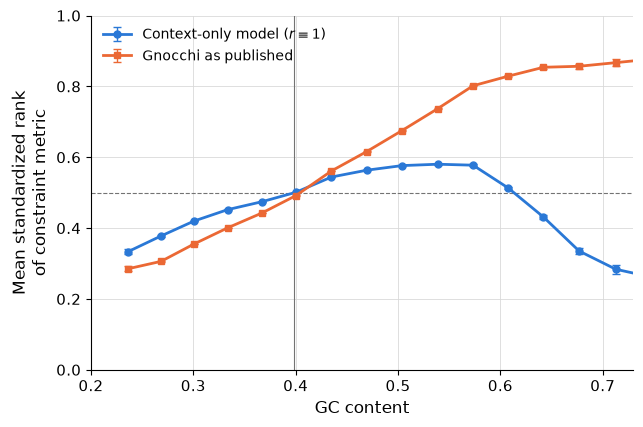

In [4]:
binned_dr = None
if DEPLETION_RANK_BED:
    binned_dr = DR.bin_depletion_rank(DR.load_depletion_rank_windows(DEPLETION_RANK_BED),
                                      n_bins=N_BINS)
else:
    print("DEPLETION_RANK_BED is not set -- panel A gets two curves instead of three.")

curves_a = [
    panels.curve_from_binned(binned_a, "step1", "step1", r"Context-only model ($r \equiv 1$)"),
    panels.curve_from_binned(binned_a, "step2", "step2", "Gnocchi as published"),
]
if binned_dr is not None:
    curves_a.append(panels.curve_from_binned(binned_dr, "dr", "dr",
                                             "Depletion rank (Halldorsson windows)"))

fig, ax = plt.subplots(figsize=FIGSIZE)
panels.panel_rank_bias(ax, curves_a, gc_mean=gc_mean, xrange=XRANGE, min_n=MIN_N_WINDOWS)
save(fig, "A")

## Panel B — the adjustment Gnocchi applies, decomposed by CpG status

**Per-context expected counts.** Group step 1's sum by trinucleotide context $t$ — the
level $r$ is fit at — writing $c\!\to\!t$ for the classes $c=(t,m)$ sharing context $t$:

$$E_1^{t}(w)=\sum_{c\to t} n_c(w)\,p_c, \qquad E_1(w)=\sum_t E_1^{t}(w).$$

Because $r_t(w)$ carries no methylation index, it comes out of the inner sum, and step 2
is a *reweighting of the same per-context counts*:

$$E_2^{t}(w)=\sum_{c\to t} n_c(w)\,p_c\,r_t(w)=E_1^{t}(w)\,r_t(w),
\qquad E_2(w)=\sum_t E_1^{t}(w)\,r_t(w).$$

**What one window receives.** Dividing,

$$r_{\mathrm{eff}}(w)=\frac{E_2(w)}{E_1(w)}=\sum_t \omega_t(w)\,r_t(w),
\qquad \omega_t(w)=\frac{E_1^{t}(w)}{E_1(w)},\quad \sum_t \omega_t(w)=1,$$

an $E_1$-weighted mean of the per-context $r$. This is why $r_{\mathrm{eff}}$, not any
single $r_t$, is the quantity the score sees: two windows with identical $r_t$ still
receive different adjustments if their context composition differs — and context
composition is precisely what varies with GC.

**What a GC bin receives.** Aggregate a bin $g$ as a **ratio of summed expected counts**:

$$R_{\mathrm{eff}}(g)=\frac{\sum_{w\in g}E_2(w)}{\sum_{w\in g}E_1(w)}
=\sum_{w\in g} W(w)\,r_{\mathrm{eff}}(w),
\qquad W(w)=\frac{E_1(w)}{\sum_{w'\in g}E_1(w')},$$

again an $E_1$-weighted mean, of the window-level $r_{\mathrm{eff}}$ this time. Expected
counts add, so this is the adjustment the bin actually receives; an unweighted mean of
$r_{\mathrm{eff}}(w)$ would weight a 3-site window like a 400-site one and answer a
different question.

**Splitting at CpG.** Let $\mathcal K=\{\mathrm{ACG,CCG,GCG,TCG}\}$ and write
$E_M^{\mathcal K}=\sum_{t\in\mathcal K}E_M^{t}$, $E_M^{\neg\mathcal K}=E_M-E_M^{\mathcal K}$
for $M\in\{1,2\}$. Define each part's own adjustment, and the CpG share of the step-1
counts:

$$R_{\mathrm{CpG}}(g)=\frac{\sum_{w\in g}E_2^{\mathcal K}(w)}{\sum_{w\in g}E_1^{\mathcal K}(w)},
\qquad
R_{\mathrm{non}}(g)=\frac{\sum_{w\in g}E_2^{\neg\mathcal K}(w)}{\sum_{w\in g}E_1^{\neg\mathcal K}(w)},
\qquad
\Pi(g)=\frac{\sum_{w\in g}E_1^{\mathcal K}(w)}{\sum_{w\in g}E_1(w)} .$$

Then, splitting the numerator of $R_{\mathrm{eff}}$ and multiplying each term by 1,

$$R_{\mathrm{eff}}(g)
=\frac{\sum_g E_2^{\mathcal K}+\sum_g E_2^{\neg\mathcal K}}{\sum_g E_1}
=\frac{\sum_g E_1^{\mathcal K}}{\sum_g E_1}\cdot\frac{\sum_g E_2^{\mathcal K}}{\sum_g E_1^{\mathcal K}}
+\frac{\sum_g E_1^{\neg\mathcal K}}{\sum_g E_1}\cdot\frac{\sum_g E_2^{\neg\mathcal K}}{\sum_g E_1^{\neg\mathcal K}}
=\Pi(g)\,R_{\mathrm{CpG}}(g)+\big(1-\Pi(g)\big)\,R_{\mathrm{non}}(g),$$

using only that expected counts add and that $\sum_g E_1^{\neg\mathcal K}/\sum_g E_1=1-\Pi(g)$.
This is an **exact identity**, not a fit, so the panel reads additively.

**Reading the panel.** Its four curves are these symbols, in this order:
$R_{\mathrm{eff}}$ (violet, what Gnocchi applies), $R_{\mathrm{non}}$ (orange) and
$R_{\mathrm{CpG}}$ (green) — the two terms it decomposes into — and the dashed grey
counterfactual derived next. The y-axis is $R(g)$ itself, a ratio of summed expected
counts, so 1 means *no adjustment* and the horizontal line at 1 is the null. Since
$R_{\mathrm{eff}}$ is a $\Pi$-weighted average of the other two, it must lie between
them: it tracks $R_{\mathrm{non}}$ closely at low GC, where $\Pi$ is small, and is pulled
down towards $R_{\mathrm{CpG}}\approx1$ as $\Pi$ grows.

**The counterfactual, and what it intervenes on.** The question is how much of
$R_{\mathrm{eff}}$'s rise the CpG contexts could account for on their own. So switch off
the *non-CpG* adjustment — set $r_t\equiv1$ for $t\notin\mathcal K$, which sends
$E_2^{\neg\mathcal K}\!\to\!E_1^{\neg\mathcal K}$ — and change nothing else: the fitted
$r_{\mathrm{CpG}}$ stays, the weights $\Pi(g)$ stay. The dashed grey curve is

$$R_{\mathrm{eff}}\big|_{r_{\mathrm{non}}\equiv1}(g)
=\frac{\sum_g E_2^{\mathcal K}+\sum_g E_1^{\neg\mathcal K}}{\sum_g E_1}
=\Pi(g)\,R_{\mathrm{CpG}}(g)+\big(1-\Pi(g)\big),$$

i.e. **what Gnocchi would apply if it adjusted CpG contexts alone**. It is flat within
0.6% across the whole GC range while $R_{\mathrm{eff}}$ climbs to 1.44, so *none* of the
applied trend survives the removal of the non-CpG term: the GC dependence of what Gnocchi
applies is wholly non-CpG.

Flatness here is a result, not an identity. $\Pi$ reaches **0.43** at high GC, so a GC
trend in $R_{\mathrm{CpG}}$ would appear in this curve scaled by $\Pi$, not erased — the
curve is flat because $R_{\mathrm{CpG}}$ itself is (0.98–1.00), which is the next
paragraph's subject and is *correct* rather than a failure.

**Where each quantity comes from.** `data._r_eff_components` builds the four per-window
sums, one SQL query, and `data.r_eff_by_gc` does the binning and the divisions:

| symbol | column | built from |
|---|---|---|
| $E_1(w)$ | `e1` | `expected_counts_by_context_methyl_genome_1kb.txt` — published, already summed over all 32 contexts, $r\equiv1$ |
| $E_2(w)$ | `e2` | `refits/expected_counts_by_context_methyl_genome_1kb.{pop}.txt` — the same windows after the refit's $r$ |
| $E_1^{\mathcal K}(w)$ | `e1_cpg` | `expected_counts_per_context_methyl_genome_1kb.txt`, the per-$(w,t)$ export, restricted to $t\in\mathcal K$ and summed |
| $E_2^{\mathcal K}(w)$ | `e2_cpg` | the same rows times `rr` from `refits/rr_by_context.{pop}.txt`, the per-$(w,t)$ adjustment |
| $E_1^{\neg\mathcal K},E_2^{\neg\mathcal K}$ | — | subtraction, `e1 - e1_cpg` and `e2 - e2_cpg` |

The subtraction is why only the CpG slice of the two multi-GB per-context files is ever
joined: an 85M × 85M join becomes 10M × 10M. It also means the identity above mixes two
published files — totals from the summed export, CpG parts from the per-context one — so
it needs them to describe the same counts. They do:
`preconditions/verify_expected_r1.py` regenerates the first from the second genome-wide,
`possible` exactly and `expected` to $4.6\times10^{-5}$ relative.

$R_{\mathrm{eff}}$, $R_{\mathrm{CpG}}$, $R_{\mathrm{non}}$, $\Pi$ and the counterfactual
are then the columns `r_eff`, `r_cpg`, `r_non`, `pi_cpg`, `r_counterfactual`. One further
column, `r_eff_published` $=\sum_g E_2^{\mathrm{pub}}/\sum_g E_1$, replaces the refit's
numerator with Chen et al.'s own published `expected`. It needs no per-context $r$, which
is what makes it a check rather than a restatement: the two agree to $10^{-4}$ per bin,
and that is what licenses using the refit's per-context $r$ above — the published pipeline
writes its own only to a local directory, never to the bucket.

**Why $R_{\mathrm{CpG}}\approx1$ is correct, not a failure.** CpG mutability is dominated
by methylation, and $p_c$ is already keyed by methylation level — across methylation 0 to
15 the CpG C>T rate spans **3.0–4.3×** depending on context, the largest single rate
effect in the model, inside one trinucleotide. High-GC CpGs are CpG islands: **90–100%
hypomethylated above GC 0.70**, against ~2% in the GC bulk, and their empirical DNM rate
falls from 0.53 in the bulk to 0.19 in the top GC bin (**2.8×**). **Step 1 has already
applied that correction**,
via the covariation of GC content with methylation, so there is nothing left for $r$ to
adjust. (Chen et al. also strip `GC_content`, `CpG_island`, `Nucleosome`, `SINE` and
`met_sperm` from CpG-context models, so those models could not express a GC dependence
even if one were needed.) The GC trend in what Gnocchi applies is therefore entirely
non-CpG — which is where the rest of this figure looks.

reusing /Users/petermchale/gnomad_nc_constraint/fig5/output/r_eff_components.full.parquet


refit validation: max |r_eff(refit) - r_eff(published)| over 20 GC bins = 1.01e-04 (median 3.89e-06)


wrote /Users/petermchale/gnomad_nc_constraint/fig5/output/fig5B.pdf


gc_mid,n,pi_cpg,r_eff,r_cpg,r_non,r_counterfactual
f64,u32,f64,f64,f64,f64,f64
0.236184,1212,0.025077,0.956945,0.990545,0.956081,0.999763
0.268475,23729,0.029732,0.952518,0.991421,0.951325,0.999745
0.300542,127803,0.03723,0.960325,0.993222,0.959053,0.999748
0.333478,283824,0.046333,0.969429,0.993614,0.968254,0.999704
0.367076,382504,0.058685,0.980456,0.995619,0.97951,0.999743
…,…,…,…,…,…,…
0.607605,7652,0.219275,1.205363,0.997974,1.263611,0.999556
0.642128,2624,0.272455,1.291926,0.992815,1.403939,0.998042
0.676895,1000,0.330021,1.361819,0.988571,1.545676,0.996228


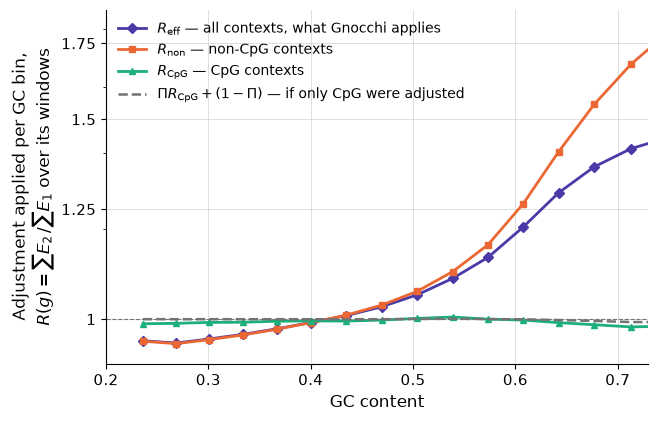

In [5]:
binned_b = D.r_eff_by_gc(df_win, edges, pop="full", cache_dir=CACHE_DIR)

fig, ax = plt.subplots(figsize=FIGSIZE)
panels.panel_r_eff(ax, binned_b, min_n=MIN_N_WINDOWS, xrange=XRANGE)
save(fig, "B")

binned_b.filter(pl.col("n") >= MIN_N_WINDOWS).select(
    ["gc_mid", "n", "pi_cpg", "r_eff", "r_cpg", "r_non", "r_counterfactual"])

## Panel C — the training set is not the scored population

$r$ is fit on de novo mutations and matched background sites drawn from the **whole
genome**, but applied to — and Gnocchi scored on — noncoding, `pass_qc`, autosome/PAR
windows. Panel C measures how far apart those two populations drift with GC.

Map each non-CpG training site — **both classes, DNMs and background sites alike** — to
its containing 1 kb tile and partition the sites of GC bin $g$ three ways:

$$N(g)=N_{\mathrm{noncoding}}(g)+N_{\mathrm{coding}}(g)+N_{\mathrm{QC}}(g),$$

where *noncoding* means the tile is in the scored population, *coding* that it is in the
constraint table but coding, and *QC* that it is not in that table at all. The stack
plots the three fractions, which sum to 1 by construction.

**Why both classes.** In a case-control design it is the controls that carry the
covariate distribution, which is the argument for stacking the background class alone —
and it is an argument about the *design*, not about the *fit*. The fit minimizes its loss
over the mixture of the two classes, so the mixture is the training distribution, and the
training distribution is what this row is comparing against the scored population.
Restricted to the background class the stack is almost the same picture — the QC-fail band
runs 0.13 → 0.24 across the plotted range instead of 0.14 → 0.28 — because the background
class outnumbers the DNMs about 12:1. What the DNM class adds is its own, steeper drift:
at GC 0.64 it is 64% QC-fail against the background class's 26%.

**What the two rows are between them.** The upper row is *covariate shift*: $P(x)$ in the
training data is not $P(x)$ in the scored data, and the gap grows with GC. The lower row
is *concept shift*: $P(\mathrm{DNM}\mid x)$ is not the same function in the territory that
drops out. Both are driven by one latent variable — which of the three window classes a
site sits in — and $r$ cannot see it: the model is fit per trinucleotide context on
regional features, none of which encodes window class.

One thing the drifting case-control ratio does *not* do is bias the fit by itself. Under
case-control sampling the fitted slopes are consistent for the population slopes whatever
the ratio; only the intercept shifts. Covariate shift alone would likewise be survivable,
since a correctly specified model extrapolates. It is the combination — a mis-specified
smooth fit, over a covariate range where the label-generating process is a different one —
that puts a GC slope into $r$.

**What the two lower strata are, precisely** — the labels matter here, because the
mechanism differs. A coding window *has* a published Gnocchi score; it is this analysis
that sets it aside, following McHale et al.'s noncoding restriction. A window in the
third stratum has no score at all: Chen et al. dropped it before scoring, keeping only
windows with $\ge1{,}000$ possible variants, $\ge80\%$ of observed variants PASS, and
mean coverage 25–35× (Methods; `run_nc_constraint_gnomad_v31_main.py:296`). The published
table carries `pass_qc = True` on all 1,984,900 of its rows, so that flag is inert
downstream and a QC failure shows up only as an absent row.

That third stratum is therefore **not** "no gnomAD coverage", the name it carried here
until measured: of the 587,902 absent autosomal windows, all have their QC inputs on
file, 417,097 fail the PASS rule and only 19,396 fail the coverage band. Weighted by
background training sites it is starker still — 88% PASS rule, 14% too few possible
variants, 1% coverage. Those percentages are *within* the third band, not of the training
set: 86.6% of non-CpG background sites are in QC-pass windows (80.5% noncoding, 6.1%
coding) and 13.3% in QC-fail ones. `preconditions/verify_qc_filter.py` records both, and confirms the
filter forwards too: all 1,984,900 scored windows satisfy all three conditions. Over both
training classes — the stack's own genome-wide average — it is 79.9% / 6.1% / 14.0%.

The three strata are therefore *QC-pass noncoding*, *QC-pass coding*, and *QC-fail* — and
only the first two are split by coding status. **The third is a mixture**, deliberately:
`coding_prop` lives in the constraint table and these windows have no row in it. Read from
Chen et al.'s own upstream input (`misc/genome_1kb_coding_exons.txt`), 6.9% of the QC-fail
windows overlap coding exons, against 7.1% of the QC-pass ones — so QC failure is close to
independent of coding status, and the third band is not a coding band in disguise. Site-
weighted, 5.8% of its sites are in coding-overlapping windows.

The fraction inside the scored population falls from ~0.82 in the GC bulk to under 0.28
by GC 0.68. So the model is fit on one population and applied to another, and the two
come apart exactly where panel A's bias is largest.

**The lower row shows that the excluded territory is not just absent but different**, and
that the difference is not mainly the coding part. Writing $\bar y_s(g)$ for the
empirical non-CpG DNM rate in stratum $s$ and bin $g$, it plots

$$\frac{\bar y_{\mathrm{coding}}(g)}{\bar y_{\mathrm{noncoding}}(g)}
\qquad\text{and}\qquad
\frac{\bar y_{\mathrm{QC}}(g)}{\bar y_{\mathrm{noncoding}}(g)},$$

with delta-method binomial error bars on the log ratio. A ratio of 1 would mean the
excluded sites are exchangeable with the scored ones as far as mutation rate goes. The
coding stratum sits there — within ~10%, flat across the whole range — while the
QC-failing stratum runs 1.55× in the GC bulk and **4.06× by GC 0.61**.

Both rows come from one table of per-stratum counts; this row divides the DNM count by
the site count, the row above takes the site count as a share of its bin. 72,801 of the
non-CpG autosomal DNMs fall in the QC-failing stratum, against 17,545 coding and 241,479
noncoding.

So the steep GC dependence the model learns comes from sequence gnomAD could not call
reliably, which is also where trio DNM calling is least reliable: part of that excess is
plausibly false-positive DNM calls rather than real mutation.

reusing /Users/petermchale/gnomad_nc_constraint/fig5/output/dnm_rate_by_stratum.20bins.parquet
training composition: 4,367,225 non-CpG training sites over 20 GC bins


wrote /Users/petermchale/gnomad_nc_constraint/fig5/output/fig5C.pdf
shape: (17, 5)
┌──────────┬─────────┬────────────────┬─────────────┬────────────────┐
│ gc_mid   ┆ n_total ┆ frac_noncoding ┆ frac_coding ┆ frac_failed_qc │
│ ---      ┆ ---     ┆ ---            ┆ ---         ┆ ---            │
│ f64      ┆ i64     ┆ f64            ┆ f64         ┆ f64            │
╞══════════╪═════════╪════════════════╪═════════════╪════════════════╡
│ 0.157425 ┆ 11886   ┆ 0.000168       ┆ 0.0         ┆ 0.999832       │
│ 0.227125 ┆ 2608    ┆ 0.842025       ┆ 0.013804    ┆ 0.144172       │
│ 0.261975 ┆ 51799   ┆ 0.898434       ┆ 0.030869    ┆ 0.070696       │
│ 0.296825 ┆ 286476  ┆ 0.871284       ┆ 0.050367    ┆ 0.078349       │
│ 0.331675 ┆ 648089  ┆ 0.853468       ┆ 0.052372    ┆ 0.09416        │
│ …        ┆ …       ┆ …              ┆ …           ┆ …              │
│ 0.610475 ┆ 26546   ┆ 0.437693       ┆ 0.333459    ┆ 0.228848       │
│ 0.645325 ┆ 11640   ┆ 0.32457        ┆ 0.358591    ┆ 0.316838   

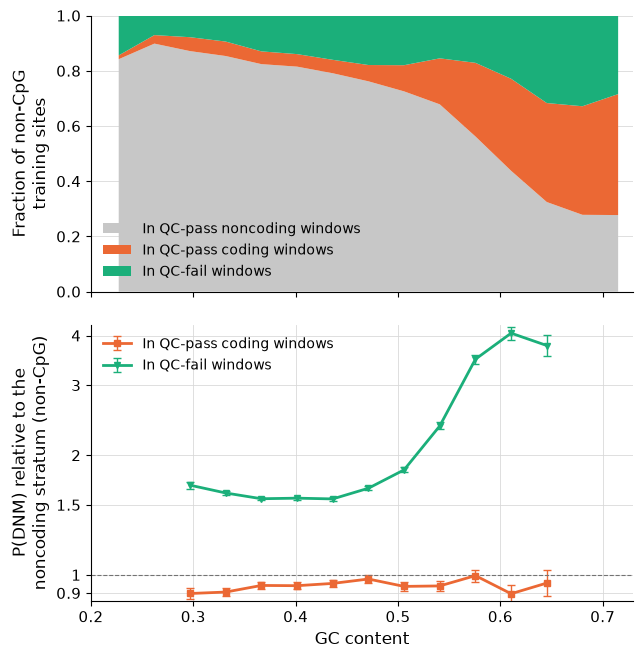

In [6]:
# One table, two rows: `st` carries each stratum's site count (the composition above) and
# its DNM count (the rate below), so the two rows cannot describe different sites.
st = D.dnm_rate_by_stratum(edges, cache_dir=CACHE_DIR)
comp = D.training_composition(st, edges)
ratios = D.stratum_ratios(st, edges)

fig, (axC1, axC2) = plt.subplots(2, 1, figsize=(FIGSIZE[0], 7.6), sharex=True,
                                 gridspec_kw={"height_ratios": [1, 1], "hspace": 0.12})
panels.panel_training_composition(axC1, comp, min_n=MIN_N_SITES, xrange=XRANGE,
                                  show_xlabel=False)
panels.panel_stratum_ratios(axC2, ratios, xrange=XRANGE)
save(fig, "C")

print(comp.filter(pl.col("n_total") >= MIN_N_SITES)
          .select(["gc_mid", "n_total", "frac_noncoding", "frac_coding", "frac_failed_qc"]))
print(ratios.select(["gc_mid", "coding_ratio", "coding_se_log",
                     "failed_qc_ratio", "failed_qc_se_log"]))

## Panel D — restricting the training set flattens the DNM rate, and the fit can then track it

For each training population and each GC bin $g$, over non-CpG sites only:

$$\widehat p(g)=\frac{1}{|S_g|}\sum_{i\in S_g}\hat\pi_i \quad\text{(fitted)},
\qquad
\bar y(g)=\frac{1}{|S_g|}\sum_{i\in S_g} y_i \quad\text{(empirical)},$$

with $y_i\in\{0,1\}$ the DNM label and $\hat\pi_i$ the site's own fitted probability from
its own context's model, evaluated at the **site's** feature vector. Each pair is a
reliability diagram on its own population, so *fitted vs empirical within a pair* is the
comparison that means something.

Levels are not comparable **across** populations: the case-control ratio differs (12.2
vs 13.5 background sites per DNM), which shifts $P(\mathrm{DNM})$ for reasons unrelated
to GC. Each curve is therefore divided by its own site-weighted mean, leaving shape only.

Three populations:

* **original** — the training set as published;
* **scored** — restricted to the analyzed windows (the intervention);
* **size-matched** — the same *number* of sites as *scored*, drawn at random from the
  whole genome. This is the control that separates "better-matched population" from
  "less data", and it lies on top of the original pair.

Two things happen at once when the training set is restricted. The **empirical** GC
dependence itself shrinks and becomes monotone — on the original set $P(\mathrm{DNM})$
rises 2.4× and then *collapses* above GC 0.66; on the scored set it rises smoothly by
1.57× with no turnover. And the logistic regression can then actually fit it: on the
original set it misses by 26% and 29% *in opposite directions*, because it is a smooth
monotone surface chasing a curve that turns over.

This is why $R_{\mathrm{non}}$ in panel B is inflated — the model has partly learned a GC
slope that belongs to sequence outside the scored population.

**Caveat.** This panel measures a *level* error in $P(\mathrm{DNM})$, and levels cancel in
$r$. It diagnoses the fit; it is not itself a measurement of Gnocchi's bias. Panel E is.

full         non-CpG: 4,355,429 sites, 330,559 DNMs, 12.2 background per DNM


scored       non-CpG: 3,490,733 sites, 241,449 DNMs, 13.5 background per DNM


sizematched  non-CpG: 3,471,825 sites, 235,307 DNMs, 13.8 background per DNM


wrote /Users/petermchale/gnomad_nc_constraint/fig5/output/fig5D.pdf

full:
 gc_mid       n    n1  mean_pred  empirical_prop
24.9220    9884   726     0.0688          0.0735
28.3489  138720 10030     0.0695          0.0723
31.8810  539742 38988     0.0707          0.0722
35.6131  946096 69084     0.0724          0.0730
39.2875 1013622 74568     0.0745          0.0736
43.0823  777307 57987     0.0766          0.0746
46.9123  485577 37955     0.0795          0.0782
50.7157  243987 19903     0.0837          0.0816
54.5551  116776 10624     0.0895          0.0910
58.4293   51282  5770     0.0986          0.1125
62.2230   20091  2909     0.1120          0.1448
66.0771    7325  1296     0.1304          0.1769
70.0518    3073   449     0.1452          0.1461
73.8314    1237   150     0.1560          0.1213

scored:
 gc_mid      n    n1  mean_pred  empirical_prop
24.9320   8889   589     0.0677          0.0663
28.3409 122154  8357     0.0684          0.0684
31.8750 461298 31732     0.0688      

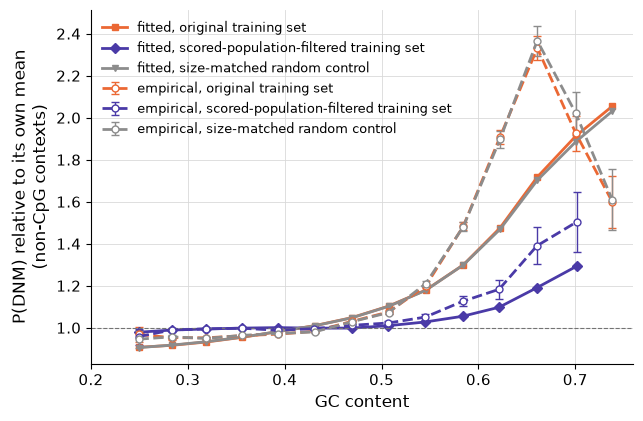

In [7]:
binned_d = D.dnm_probability(("full", "scored", "sizematched"), n_bins=N_BINS,
                             min_n=MIN_N_SITES)

fig, ax = plt.subplots(figsize=FIGSIZE)
panels.panel_dnm_probability_pairs(ax, binned_d, min_n=MIN_N_SITES, normalize=True)
save(fig, "D")

for pop, b in binned_d.items():
    print(f"\n{pop}:")
    print(b[["gc_mid", "n", "n1", "mean_pred", "empirical_prop"]].round(4).to_string(index=False))

## Panel E — refitting $r$ on the scored population removes Gnocchi's bias

Exactly one thing changes relative to the published pipeline: training sites outside the
analyzed window set are dropped. Everything downstream is identical — univariate
Bonferroni selection, standardization, `IncrementalPCA`, L1 logit per context,
genome-wide apply. So panel E is panel A's statistic with a third expected count,
$E_2^{\mathrm{scored}}$, added to the same joint $z$ filter and the same ranking.

Two controls make this a result rather than an anecdote, and both are printed below
rather than plotted (a curve indistinguishable from published Gnocchi is clutter):

* the **full-population refit** through this same code lands on published Gnocchi, so
  "before" and "after" differ by the intervention and not by whose code produced them;
* the **size-matched random refit** also lands on published Gnocchi, so the improvement
  is about *which* sites, not *how many*.

Note the retrained curve is expected to end up *better than* the context-only model, not
merely closer to it: a correct $r$ should repair the context-only model's own droop at
both GC extremes. That is the sense in which this is a positive result and not just the
removal of a defect.

  sanity check: z_step2 vs published z, max |diff| = 0.0 over 1,843,559 windows


  1,840,165 windows after joint z filtering
  mean |rank - 0.5|  step1        = 0.093  (over bins with n >= 100)
  mean |rank - 0.5|  step2        = 0.212  (over bins with n >= 100)
  mean |rank - 0.5|  scored       = 0.046  (over bins with n >= 100)
  mean |rank - 0.5|  full_refit   = 0.212  (over bins with n >= 100)
  mean |rank - 0.5|  sizematched  = 0.210  (over bins with n >= 100)
wrote /Users/petermchale/gnomad_nc_constraint/fig5/output/fig5E.pdf


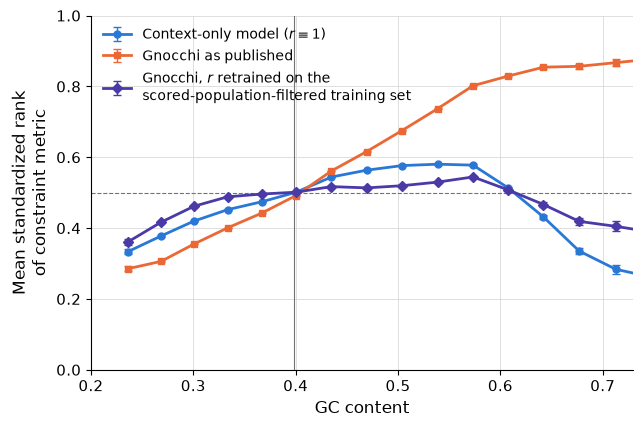

In [8]:
extra = [("scored", D.refit_path("expected", "scored"))]
CONTROLS = [("full_refit", "full"), ("sizematched", "sizematched")]
for label, pop in CONTROLS:
    extra.append((label, D.refit_path("expected", pop)))

df_e, binned_e = D.rank_curves(df_win, extra=extra, min_n=MIN_N_WINDOWS)

curves_e = [
    panels.curve_from_binned(binned_e, "step1", "step1", r"Context-only model ($r \equiv 1$)"),
    panels.curve_from_binned(binned_e, "step2", "step2", "Gnocchi as published"),
    panels.curve_from_binned(binned_e, "scored", "scored",
                             "Gnocchi, $r$ retrained on the\n"
                             "scored-population-filtered training set"),
]

fig, ax = plt.subplots(figsize=FIGSIZE)
panels.panel_rank_bias(ax, curves_e, gc_mean=float(df_e["GC_content"].mean()),
                       xrange=XRANGE, min_n=MIN_N_WINDOWS)
save(fig, "E")

## Supporting figure (**Supporting Figure 7** in the manuscript) — why $r_{\mathrm{CpG}}\approx1$ is correct

Panel B asserts that CpG contexts *should* apply no GC-dependent adjustment, because the
effect that would need adjusting has already been applied in step 1. That claim rests on
three measurements which the panel itself does not show, so they get their own figure,
`output/supp_fig7.pdf`:

**A. The size of the methylation effect step 1 absorbs.** $p_c$ is keyed by methylation
level, and for CpG C>T the fitted probability spans **3.0–4.3×** from level 0 to 15 —
within a *single* trinucleotide context, and the largest single rate effect in the model.
The dashed curves are the independent pre-saturation estimate $\mu$, rescaled to meet
each context at level 0; it spans 9.7–15.2× over the same range. The gap between them is
the saturation of $p_c$, which is a polymorphism probability and so compresses hardest
where the true rate is highest.

**B. High-GC CpGs are CpG islands.** The hypomethylated fraction (level $\leq$ 1) runs
~2.5% through the GC bulk and **90–100% above GC 0.70**; mean methylation falls from ~6.5
to near zero over the same range.

**C. So their DNM rate collapses.** Flat at ~0.53 through the bulk, falling to **0.195**
in the top GC bin — a 2.7× fall, tracking B. The top two bins hold 356 and 169 sites;
their error bars carry that.

**D. And these contexts are not a rounding error.** $\Pi$, the CpG share of a bin's step-1
expected counts — the same weight panel B's identity
$R_{\mathrm{eff}}=\Pi R_{\mathrm{CpG}}+(1-\Pi)R_{\mathrm{non}}$ uses — rises from
**0.025 to 0.426** across the GC range. So the flatness of panel B's counterfactual is a
measurement and not an artifact of negligible weight: had $R_{\mathrm{CpG}}$ carried a GC
trend, it would have reached the applied multiplier scaled by up to 0.43. This is the
panel that says the A–C mechanism *matters* rather than merely *holds*.

Put together: a large, strongly GC-dependent CpG effect exists, step 1 already applies it,
and the contexts it applies to carry up to 43% of the expected counts. There is nothing
left for $r$ to correct, which is exactly what panel B measures. (Level, not rate: these
are case-control-sampled training sites at ~10:1, so the y-axis of C is not a genome-wide
mutation rate.)

D is binned over **Chen windows** and A–C over **training sites**, the same split the main
figure runs on, so the two do not end in the same place: D's last bin above the 100-window
floor is centred at GC 0.75 against 0.78 for B and C. Note also that D is drawn on this
figure's wider 0.2–0.8 axis, so it shows the two bins (0.71 and 0.75, where $\Pi$ reaches
0.38 and 0.43) that panel B's own 0.2–0.73 range cuts off — the bins where the weight is
largest are exactly the ones the main panel cannot show.

CpG C>T, methylation 0 -> 15:  fitted_po spans 3.0-4.3x, mu spans 9.7-15.2x
reusing /Users/petermchale/gnomad_nc_constraint/fig5/output/cpg_methylation_by_gc.20bins.parquet


wrote /Users/petermchale/gnomad_nc_constraint/fig5/output/supp_fig7.pdf


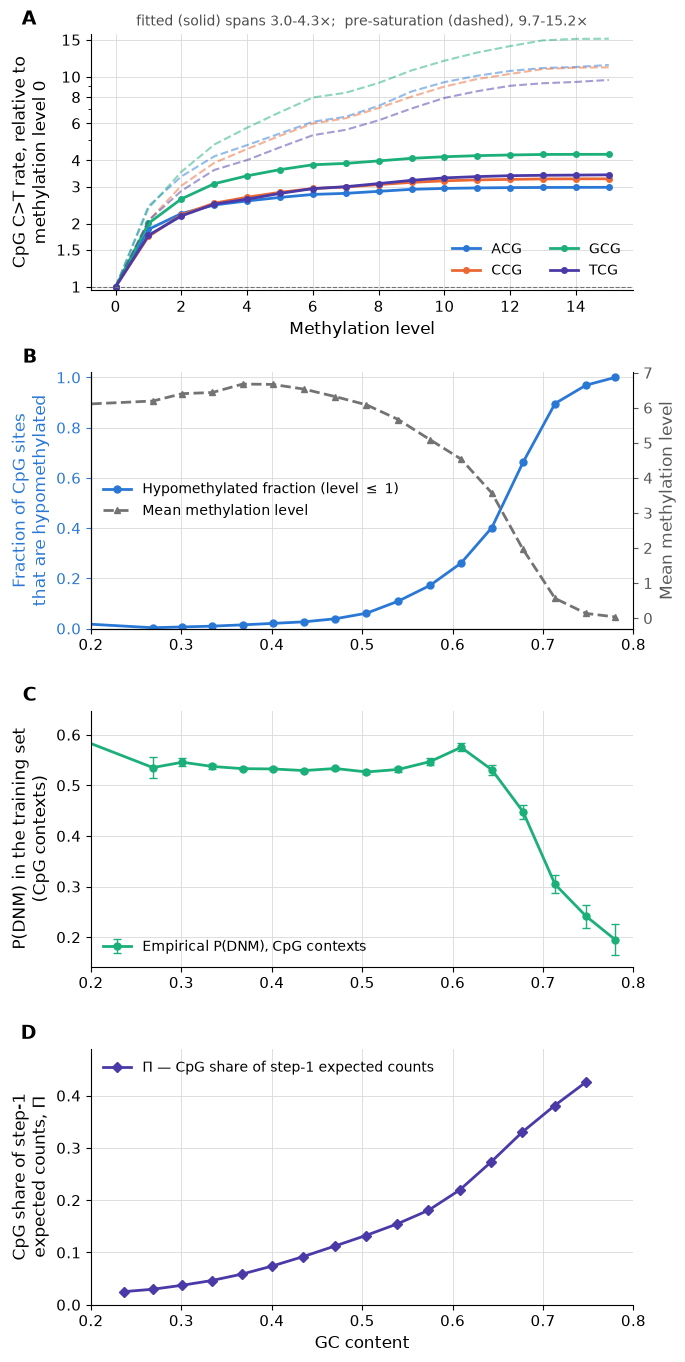

In [9]:
ct = D.cpg_rate_by_methyl(cache_dir=CACHE_DIR)
cpg = D.cpg_methylation_by_gc(edges, cache_dir=CACHE_DIR)

fig, axes = plt.subplots(4, 1, figsize=(7.0, 16.5),
                         gridspec_kw={"height_ratios": [1, 1, 1, 1], "hspace": 0.32})
panels.panel_cpg_methylation_effect(axes[0], ct)
# MIN_N_CPG, not MIN_N_SITES: the top two GC bins (n = 356 and 169) carry the claim,
# and their error bars show how thin they are. Quote numbers from this same subset.
panels.panel_cpg_hypomethylation(axes[1], cpg, min_n=MIN_N_CPG, show_xlabel=False)
panels.panel_cpg_dnm_rate(axes[2], cpg, min_n=MIN_N_CPG, show_xlabel=False)
# binned_b and MIN_N_WINDOWS, not cpg/MIN_N_CPG: Pi is a per-window weight, and this is
# the same table and the same bin floor panel B decomposes, so the curve here IS the
# weight in that identity rather than a second estimate of it.
panels.panel_cpg_expected_share(axes[3], binned_b, min_n=MIN_N_WINDOWS)
panels.label_panels(axes, ("A", "B", "C", "D"))

for ext, kw in ((".pdf", {}), (".png", {"dpi": 200})):
    fig.savefig(os.path.join(OUTPUT_DIR, f"supp_fig7{ext}"), bbox_inches="tight", **kw)
print("wrote", os.path.join(OUTPUT_DIR, "supp_fig7.pdf"))

In [10]:
shown = cpg.filter(pl.col("n") >= MIN_N_CPG)
bulk = shown.filter((pl.col("gc_pct") > 35) & (pl.col("gc_pct") < 50))
p_bulk = float(np.average(bulk["p"], weights=bulk["n"]))
top = shown.sort("gc_pct")[-1]
print(f"Supporting Figure 7B: hypomethylated fraction "
      f"{float(np.average(bulk['frac_hypomethylated'], weights=bulk['n'])):.3f} in the "
      f"GC bulk -> {shown.filter(pl.col('gc_pct') > 70)['frac_hypomethylated'].min():.2f}"
      f"-{shown['frac_hypomethylated'].max():.2f} above GC 0.70")
print(f"Supporting Figure 7C: DNM rate {p_bulk:.3f} in the GC bulk -> "
      f"{float(top['p'][0]):.3f} in the top GC bin "
      f"({p_bulk / float(top['p'][0]):.1f}x lower)")
pi = binned_b.filter(pl.col("n") >= MIN_N_WINDOWS)["pi_cpg"]
print(f"Supporting Figure 7D: CpG share of step-1 expected counts "
      f"{pi.min():.3f} -> {pi.max():.3f}")
print(shown.select(["gc_pct", "n", "mean_methyl", "frac_hypomethylated", "p"]))

Supporting Figure 7B: hypomethylated fraction 0.025 in the GC bulk -> 0.90-1.00 above GC 0.70
Supporting Figure 7C: DNM rate 0.532 in the GC bulk -> 0.195 in the top GC bin (2.7x lower)
Supporting Figure 7D: CpG share of step-1 expected counts 0.025 -> 0.426
shape: (17, 5)
┌───────────┬───────┬─────────────┬─────────────────────┬──────────┐
│ gc_pct    ┆ n     ┆ mean_methyl ┆ frac_hypomethylated ┆ p        │
│ ---       ┆ ---   ┆ ---         ┆ ---                 ┆ ---      │
│ f64       ┆ i64   ┆ f64         ┆ f64                 ┆ f64      │
╞═══════════╪═══════╪═════════════╪═════════════════════╪══════════╡
│ 16.8      ┆ 592   ┆ 6.070946    ┆ 0.023649            ┆ 0.60473  │
│ 26.852855 ┆ 613   ┆ 6.192496    ┆ 0.003263            ┆ 0.535073 │
│ 30.107929 ┆ 4061  ┆ 6.402118    ┆ 0.006402            ┆ 0.545678 │
│ 33.423656 ┆ 11329 ┆ 6.435166    ┆ 0.009533            ┆ 0.537294 │
│ 36.790797 ┆ 20265 ┆ 6.67619     ┆ 0.014755            ┆ 0.532939 │
│ …         ┆ …     ┆ …           ┆ 

## Numbers for the caption

Everything quoted in the caption should come from here, not from memory.

In [11]:
# Every number below is computed over the bins the panels actually plot -- the same
# min_n floor and, for panel C, the same x range. Otherwise a caption can quote a bin
# the reader cannot see.
print(f"panel A: {df_a.height:,} windows after joint z filtering, mean GC {gc_mean:.3f}")
for label, name in [("step1", "context-only (r = 1)"), ("step2", "Gnocchi as published")]:
    print(f"  mean |rank - 0.5|  {name:<34} {D.rank_bias(binned_a, label, MIN_N_WINDOWS):.3f}")
if binned_dr is not None:
    print(f"  mean |rank - 0.5|  {'depletion rank':<34} "
          f"{D.rank_bias(binned_dr, 'dr', MIN_N_WINDOWS):.3f}")

b = binned_b.filter(pl.col("n") >= MIN_N_WINDOWS)
print(f"\npanel B: r_non spans {b['r_non'].min():.3f}-{b['r_non'].max():.3f}; "
      f"r_CpG spans {b['r_cpg'].min():.3f}-{b['r_cpg'].max():.3f}; "
      f"counterfactual spans {b['r_counterfactual'].min():.3f}-"
      f"{b['r_counterfactual'].max():.3f}")
print(f"  CpG share of expected counts rises {b['pi_cpg'].min():.3f} -> {b['pi_cpg'].max():.3f}")

# Restricted to the plotted x range as well: the bins below it are almost entirely
# QC-failing sequence, so an unrestricted min() would report an analyzed fraction of 0.00
# from a bin the panel does not draw.
c = comp.filter((pl.col("n_total") >= MIN_N_SITES)
                & pl.col("gc_mid").is_between(*XRANGE)).sort("gc_mid")
print(f"\npanel C: {int(c['n_total'].sum()):,} non-CpG training sites in the plotted "
      f"range; QC-pass noncoding fraction {c['frac_noncoding'][0]:.2f} at GC "
      f"{c['gc_mid'][0]:.2f} -> {c['frac_noncoding'][-1]:.2f} at GC {c['gc_mid'][-1]:.2f}")

print("\npanel D: empirical P(DNM), max / min ratio within each population")
for pop, tab in binned_d.items():
    e = tab["empirical_prop"]
    print(f"  {pop:<12} {e.max() / e.min():.2f}x   "
          f"(fitted {tab['mean_pred'].max() / tab['mean_pred'].min():.2f}x)")

print(f"\npanel E: {df_e.height:,} windows after joint z filtering")
for label, name in [("step1", "context-only (r = 1)"),
                    ("step2", "Gnocchi as published"),
                    ("scored", "Gnocchi, retrained on the filtered training set"),
                    ("full_refit", "  control: refit on the full training set"),
                    ("sizematched", "  control: size-matched random subsample")]:
    print(f"  mean |rank - 0.5|  {name:<44} {D.rank_bias(binned_e, label, MIN_N_WINDOWS):.3f}")

panel A: 1,840,310 windows after joint z filtering, mean GC 0.399
  mean |rank - 0.5|  context-only (r = 1)               0.093
  mean |rank - 0.5|  Gnocchi as published               0.212

panel B: r_non spans 0.951-1.785; r_CpG spans 0.984-1.004; counterfactual spans 0.994-1.001
  CpG share of expected counts rises 0.025 -> 0.426

panel C: 4,353,742 non-CpG training sites in the plotted range; QC-pass noncoding fraction 0.84 at GC 0.23 -> 0.28 at GC 0.72

panel D: empirical P(DNM), max / min ratio within each population
  full         2.45x   (fitted 2.27x)
  scored       1.57x   (fitted 1.32x)
  sizematched  2.50x   (fitted 2.24x)

panel E: 1,840,165 windows after joint z filtering
  mean |rank - 0.5|  context-only (r = 1)                         0.093
  mean |rank - 0.5|  Gnocchi as published                         0.212
  mean |rank - 0.5|  Gnocchi, retrained on the filtered training set 0.046
  mean |rank - 0.5|    control: refit on the full training set    0.212
  mean |rank -

## Caveats that belong in the caption

* **Panel D is in-sample.** The retrained model is fit on training sites in the analyzed
  windows and scored against the labels of those same sites. Panel E is the
  out-of-sample confirmation: it is measured on gnomAD polymorphism counts, which the
  DNM model never sees. A held-out DNM split would make panel D airtight; it has not
  been run.
* **The depletion-rank curve comes from a different window set** (Halldorsson windows, a
  different window size) than the two Gnocchi curves. They are not joined; each is
  ranked within itself.
* **`GENEHANCER_BED` is unavailable**, so "the scored population" is noncoding +
  `pass_qc` + autosome/PAR without the enhancer exclusion — the same definition in every
  panel, including the population the retrained model is fit on.
* **This is not a proposed Gnocchi 2.0.** It is a demonstration that the bias is
  attributable to the training/scoring population mismatch. A corrected score would have
  to decide what the scored population is *before* fitting, and that choice is not
  obvious. A different route entirely (`chen_formula.tex` §9, migrated here): since DNMs
  buy freedom from selection at the price of sparsity — introducing bias exactly where
  they were meant to help — perhaps the attempt to avoid a selection-contaminated
  training set was misguided, and it is better to tolerate some contamination in exchange
  for a less biased score where it matters. That would mean capturing the $x$ dependence
  of $p_c(x) = \sigma(\beta_c \cdot x)$ by training directly on dense gnomAD data,
  rather than factorizing it and fitting one factor on sparse DNMs. It needs a new
  training process and was out of scope for the rebuttal.

## Refresh the Illustrator assembly

The manuscript figure is assembled in `fig5.ai` from the panel PDFs above, as **links**.
Any panel this run rewrote therefore leaves that file stale, and the repo -- which tracks
`fig5.ai` and is the source of truth for it -- would carry an assembly that disagrees with
its own panels until Illustrator reloads the links and the document is saved.

The cell below does that, so a notebook run ends with everything in step. It relinks only
the panels newer than the .ai, and prints each one: relinking preserves a placed item's
frame rather than its aspect ratio, so a panel whose bounding box moved is worth a look.
Nothing here is required to build the figure -- without Illustrator, or without the .ai,
it prints a notice and moves on. `fig5/resave_ai.py` is the same code as a command.

In [12]:
import resave_ai

_ = resave_ai.refresh(quiet_if_absent=True)   # the return code is for the shell, not here

6 panel PDF(s) newer than fig5.ai: fig5A.pdf, fig5B.pdf, fig5C.pdf, fig5D.pdf, fig5E.pdf, supp_fig7.pdf


relinked: fig5E.pdf, fig5D.pdf, fig5C.pdf, fig5B.pdf, fig5A.pdf
not linked in fig5.ai, so left alone: supp_fig7.pdf
saved fig5.ai
Check the relinked panels: a changed bounding box is stretched into the old frame.
Undo with: git checkout fig5/fig5.ai
